# This demo shows how to assess data quality.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.pylab import mpl
from matplotlib import font_manager
from matplotlib import rcParams
import numpy as np
import pandas as pd
import copy
import seaborn as sns
from scipy import stats
import scipy.stats.kde as kde
import pickle

import data_quality_assessment
import preprocess

## 1. Get orignal data 

1.1 Get original data and organize it

In [2]:
# get data by influxdb_API, please refer to it.
start_time = '2022-06-22 00:00:00'
end_time = '2022-10-01 00:00:00'
vrf_id = 'vrf_0000CC311178CCM262323410008787JG'
power_vrf_id = 'mDev_EMeter_Roof_MDV_7'
num_indoor = [0, 1, 2]
data_point = preprocess.data_point(vrf_id=vrf_id, power_vrf_id=power_vrf_id, num_indoor=num_indoor)
data = preprocess.get_data(data_point, start_time, end_time, rsp_time='15 min')

# differentiate the meter data
data['Qin'] = data['Qin'].diff()
data['Pvrf'] = data['Pvrf'].diff()
data['Pvrf_sys'] = data['Pvrf_sys'].diff()
# unified units into KW, convenient to plot
data['Qin'] = data['Qin'] / 0.25
data['Pvrf'] = data['Pvrf'] / 0.25
data['Pvrf_sys'] = data['Pvrf_sys'] / 0.25
data['Qs'] = data['Qs'] / 1000
data['Qac'] = data['Qac'] / 1000
data['Qac_sys'] = data['Qac_sys'] / 1000
for indoor_num in num_indoor:
    data[f'Qac{indoor_num}'] = data[f'Qac{indoor_num}'] / 1000

# calculate average temperature
data['Ti'] = data.filter(like='Ti').mean(axis=1)

# merge
data['Pvrf'] = data.apply(lambda row: row['Pvrf'] if pd.notnull(row['Pvrf']) else row['Pvrf_sys'], axis=1)
data['Qac'] = data.apply(lambda row: row['Qac'] if pd.notnull(row['Qac']) else row['Qac_sys'], axis=1)

# organize
order = ['Ti', 'Ta', 'Qs', 'Qin', 'Qac', 'Pvrf']
for indoor_num in num_indoor:
    order.append(f'Ti{indoor_num}')
    order.append(f'Sc{indoor_num}')
    order.append(f'Qac{indoor_num}')
data = data[order]

print(data.shape)
data

(9697, 15)


,Ti,Ta,Qs,Qin,Qac,Pvrf,Ti0,Sc0,Qac0,Ti1,Sc1,Qac1,Ti2,Sc2,Qac2
2022-06-22 00:00:00,30.531373,28.600000,0.0,NaN,0.0,NaN,31.3000,0.0,0.0,30.505882,0.0,0.0,29.788235,0.0,0.0
2022-06-22 00:15:00,30.501852,28.566667,0.0,7.32,0.0,0.000000e+00,31.3000,0.0,0.0,30.500000,0.0,0.0,29.705556,0.0,0.0
2022-06-22 00:30:00,30.503704,28.466667,0.0,6.56,0.0,4.000000e-02,31.3000,0.0,0.0,30.500000,0.0,0.0,29.711111,0.0,0.0
2022-06-22 00:45:00,30.500000,28.400000,0.0,4.60,0.0,0.000000e+00,31.3000,0.0,0.0,30.500000,0.0,0.0,29.700000,0.0,0.0
2022-06-22 01:00:00,30.529412,28.400000,0.0,4.88,0.0,0.000000e+00,31.3000,0.0,0.0,30.588235,0.0,0.0,29.700000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30 23:00:00,30.970833,NaN,NaN,NaN,0.0,0.000000e+00,30.7125,0.0,NaN,31.700000,0.0,NaN,30.500000,0.0,NaN
2022-09-30 23:15:00,31.020000,NaN,NaN,NaN,0.0,-9.094947e-13,30.8000,0.0,NaN,31.700000,0.0,NaN,30.560000,0.0,NaN
2022-09-30 23:30:00,31.033333,NaN,NaN,NaN,0.0,9.094947e-13,30.8000,0.0,NaN,31.700000,0.0,NaN,30.600000,0.0,NaN
2022-09-30 23:45:00,31.070000,NaN,NaN,NaN,0.0,-9.094947e-13,30.8300,0.0,NaN,31.710000,0.0,NaN,30.670000,0.0,NaN


1.2 Show original data

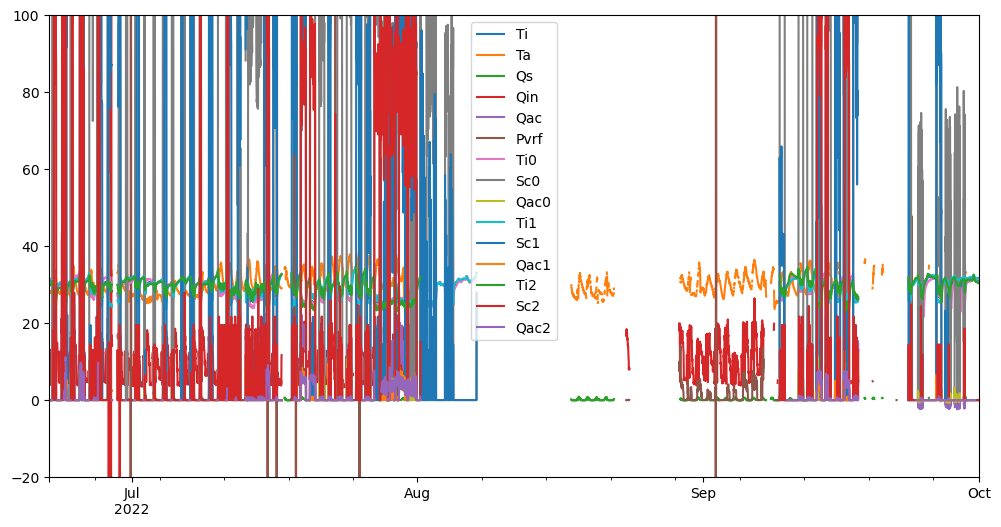

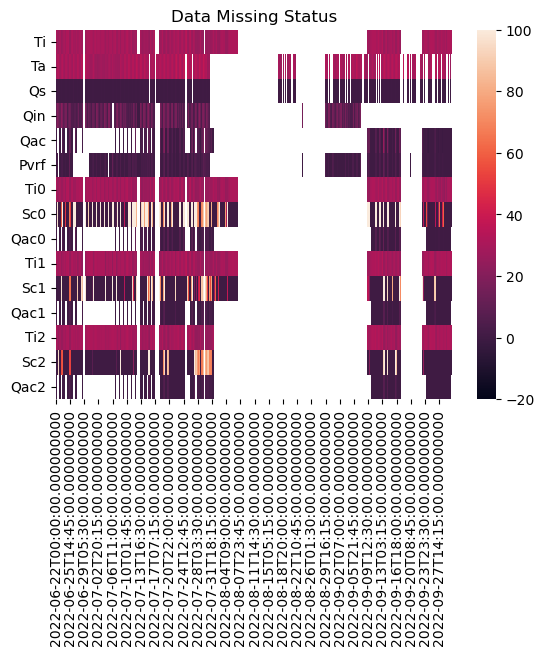

In [3]:
data.plot(figsize=(12,6))
plt.ylim(-20, 100)
plt.show()

sns.heatmap(data.T, vmin=-20, vmax=100)
plt.title('Data Missing Status')
plt.show()

## 2. Assess data quality

2.1 Set parameters

In [4]:
data_range = {
    'Ti': (-10, 50),
    'Ta': (-10, 50),
    'Qs': (0, 100),
    'Qin': (0, 100),
    'Qac': (0, 100),
    'Pvrf': (0, 200),
}
for indoor_num in num_indoor:
    data_range[f'Ti{indoor_num}'] = (-10, 50)
    data_range[f'Qac{indoor_num}'] = (0, 100)
    data_range[f'Sc{indoor_num}'] = (0, 400)

params = {
    'data_range': data_range,
    'sampling_rate': 4,
    'days_backward': 2,
    'label': 'original',
}

2.2 Assess


Statistic----------------------------------------
                Ti           Ta           Qs            Qin          Qac  \
count  5771.000000  6007.000000  6007.000000    4441.000000  3467.000000   
mean     28.961238    30.511754     0.159956     107.189756     3.810691   
std       2.277356     2.742916     0.208783    8325.619560     5.711830   
min      23.685185    23.700000     0.000000 -131199.240000    -2.393567   
25%      27.017593    28.400000     0.000000       5.360000     0.000000   
50%      29.266667    30.100000     0.020000      10.520000     0.000000   
75%      30.866667    32.433333     0.289833      15.600000     6.459466   
max      34.800000    38.533333     0.873000  180361.440000    33.046160   

               Pvrf          Ti0          Sc0         Qac0          Ti1  \
count   5709.000000  5730.000000  5730.000000  3262.000000  5770.000000   
mean       7.301409    28.616974    41.259062     2.053352    28.988901   
std      559.866166     2.490355    55.

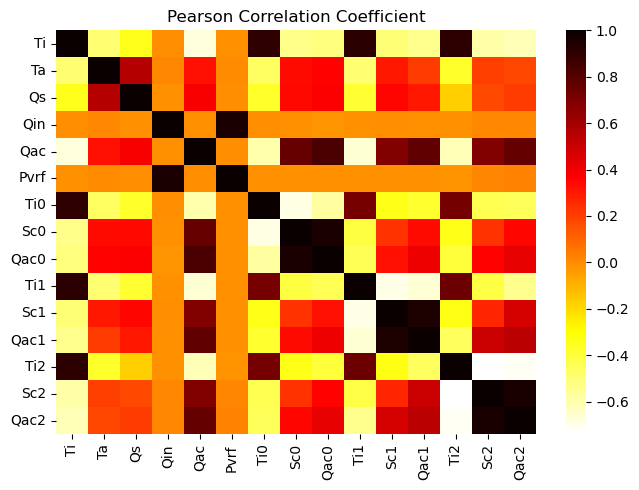


Usability----------------------------------------
('original', 'Ti'): int和float类型数据的数量为9697, 数据总数为9697, 有效数据占比为 100.00%.
('original', 'Ta'): int和float类型数据的数量为9697, 数据总数为9697, 有效数据占比为 100.00%.
('original', 'Qs'): int和float类型数据的数量为9697, 数据总数为9697, 有效数据占比为 100.00%.
('original', 'Qin'): int和float类型数据的数量为9697, 数据总数为9697, 有效数据占比为 100.00%.
('original', 'Qac'): int和float类型数据的数量为9697, 数据总数为9697, 有效数据占比为 100.00%.
('original', 'Pvrf'): int和float类型数据的数量为9697, 数据总数为9697, 有效数据占比为 100.00%.
('original', 'Ti0'): int和float类型数据的数量为9697, 数据总数为9697, 有效数据占比为 100.00%.
('original', 'Sc0'): int和float类型数据的数量为9697, 数据总数为9697, 有效数据占比为 100.00%.
('original', 'Qac0'): int和float类型数据的数量为9697, 数据总数为9697, 有效数据占比为 100.00%.
('original', 'Ti1'): int和float类型数据的数量为9697, 数据总数为9697, 有效数据占比为 100.00%.
('original', 'Sc1'): int和float类型数据的数量为9697, 数据总数为9697, 有效数据占比为 100.00%.
('original', 'Qac1'): int和float类型数据的数量为9697, 数据总数为9697, 有效数据占比为 100.00%.
('original', 'Ti2'): int和float类型数据的数量为9697, 数据总数为9697, 有效数据占比为 100.00%.
('original', 

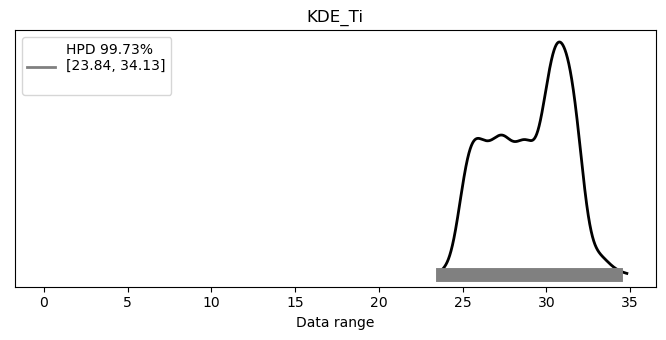

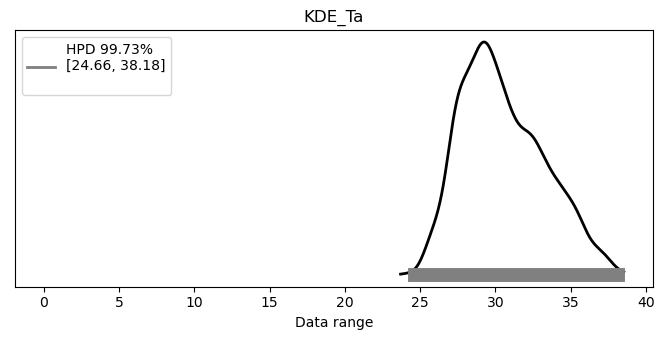

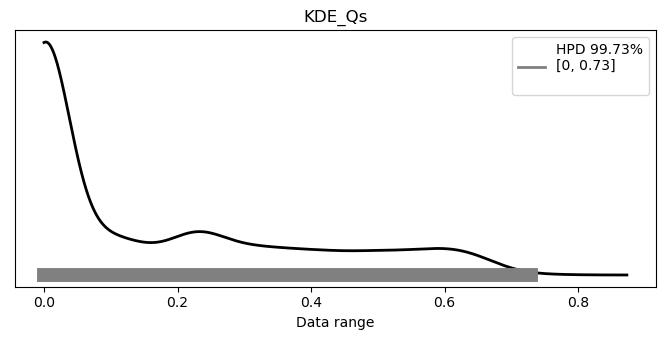

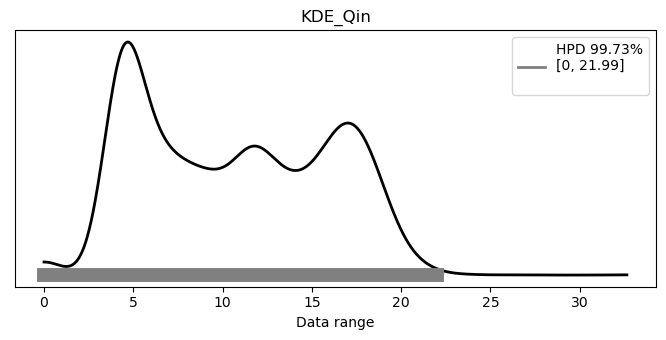

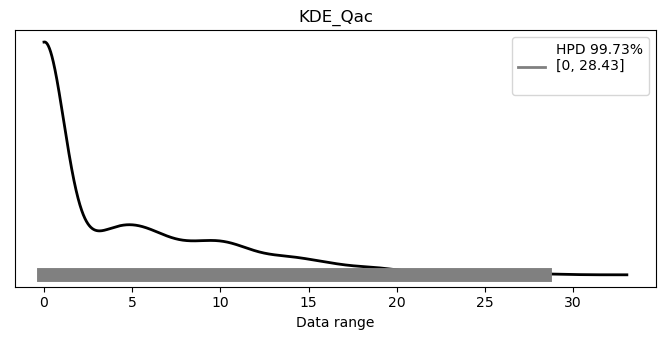

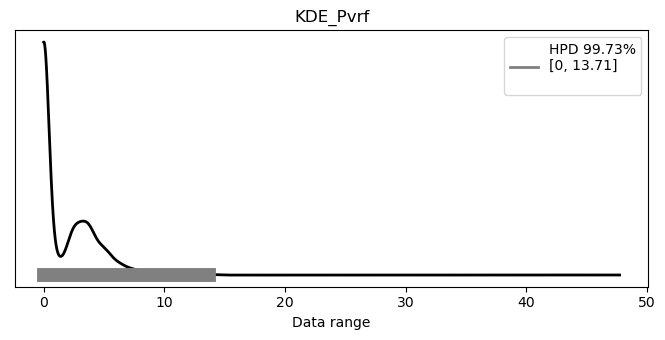

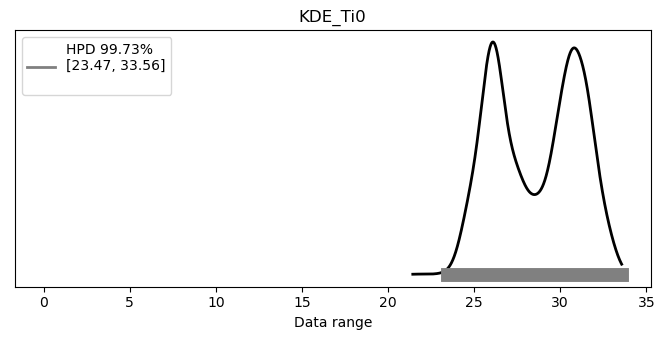

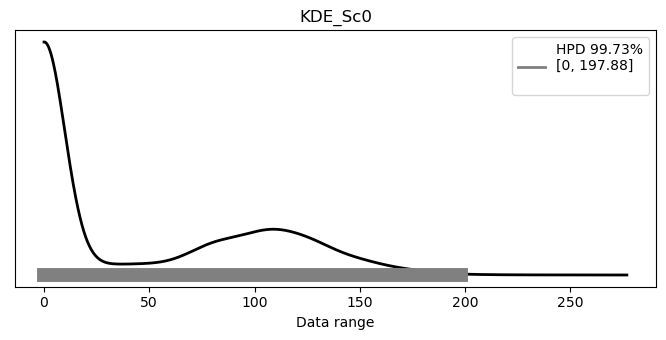

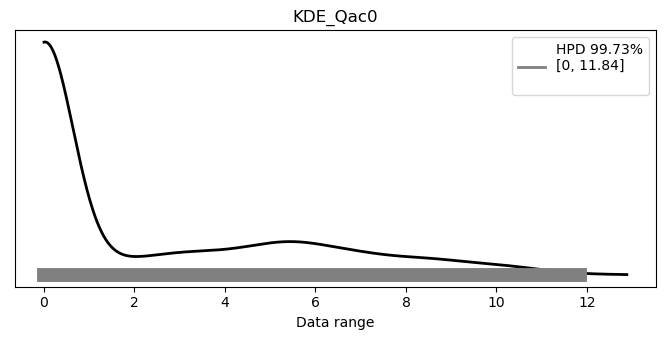

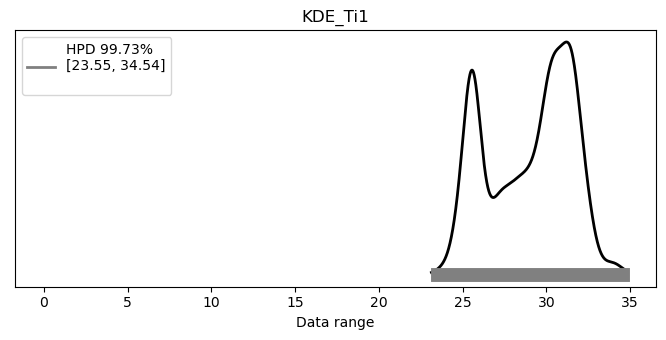

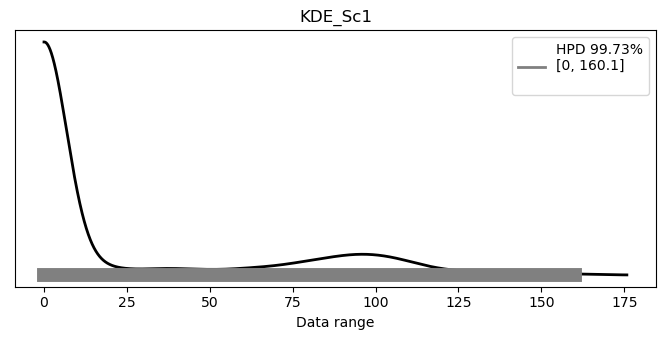

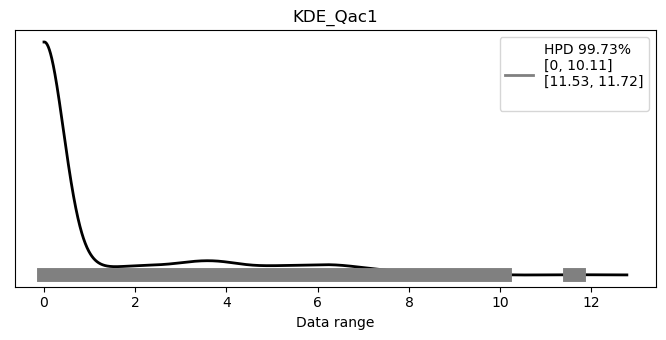

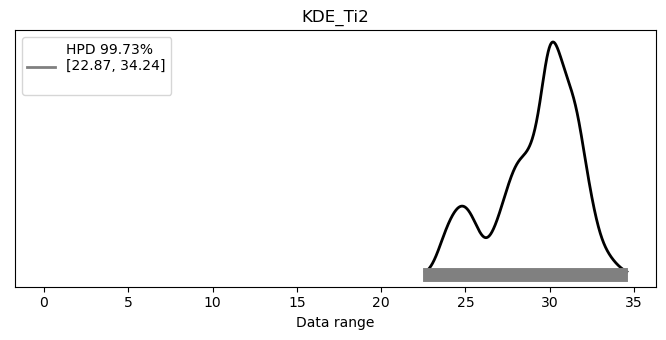

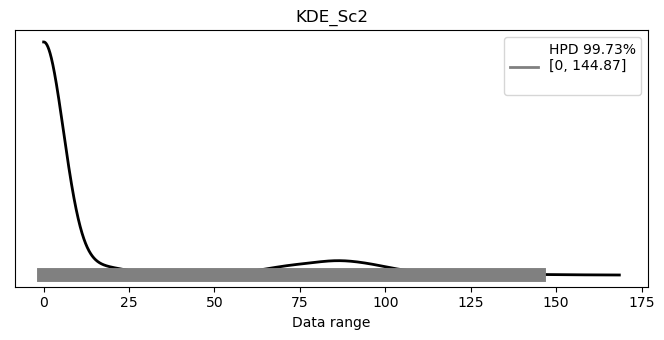

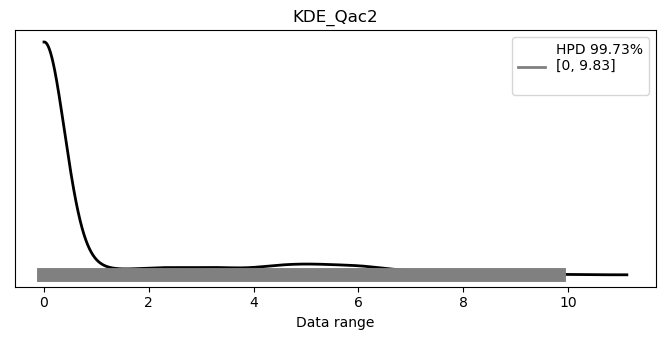


Completeness----------------------------------------
('original', 'Ti') 总缺失率:  40.49%
('original', 'Ta') 总缺失率:  38.05%
('original', 'Qs') 总缺失率:  38.05%
('original', 'Qin') 总缺失率:  54.20%
('original', 'Qac') 总缺失率:  64.25%
('original', 'Pvrf') 总缺失率:  41.13%
('original', 'Ti0') 总缺失率:  40.91%
('original', 'Sc0') 总缺失率:  40.91%
('original', 'Qac0') 总缺失率:  66.36%
('original', 'Ti1') 总缺失率:  40.50%
('original', 'Sc1') 总缺失率:  40.50%
('original', 'Qac1') 总缺失率:  66.36%
('original', 'Ti2') 总缺失率:  46.97%
('original', 'Sc2') 总缺失率:  46.97%
('original', 'Qac2') 总缺失率:  66.36%


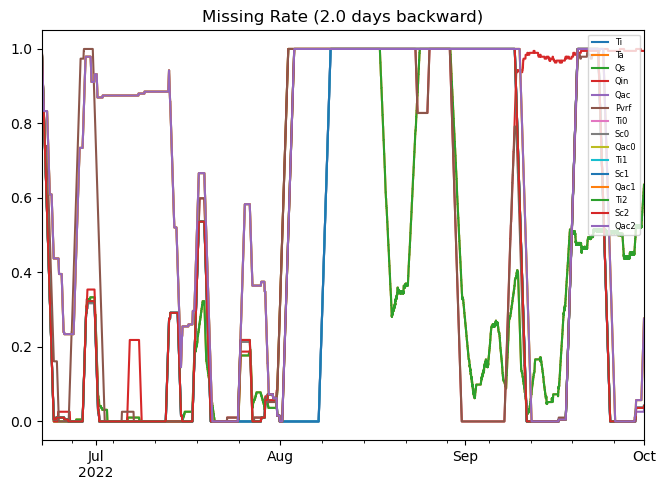

statistics of missing rate:
                Ti           Ta           Qs          Qin          Qac  \
count  9697.000000  9697.000000  9697.000000  9697.000000  9697.000000   
mean      0.414395     0.383363     0.383363     0.542097     0.652051   
std       0.457525     0.377200     0.377200     0.457722     0.398817   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000     0.036458     0.036458     0.000000     0.255208   
50%       0.098958     0.265625     0.265625     0.739583     0.875000   
75%       1.000000     0.625000     0.625000     1.000000     1.000000   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

              Pvrf          Ti0          Sc0         Qac0          Ti1  \
count  9697.000000  9697.000000  9697.000000  9697.000000  9697.000000   
mean      0.420779     0.418623     0.418623     0.669286     0.414498   
std       0.447288     0.454581     0.454581     0.390817     0.457489   
min      

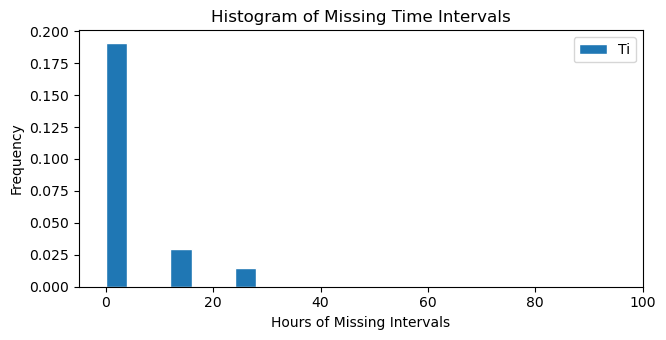

('original', 'Ta') missing intervals <= 4h:  99.43%.
('original', 'Ta') missing intervals <= 0.5h:  92.92%.
1039 1045


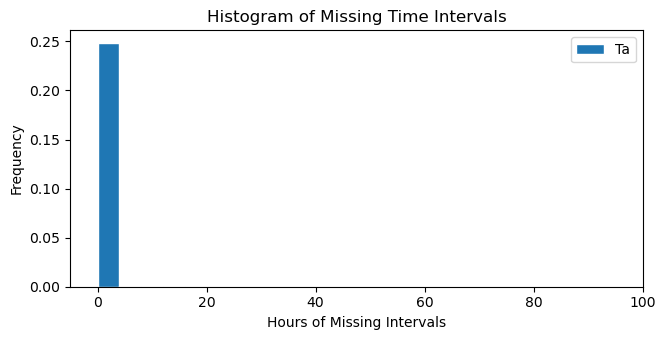

('original', 'Qs') missing intervals <= 4h:  99.43%.
('original', 'Qs') missing intervals <= 0.5h:  92.92%.
1039 1045


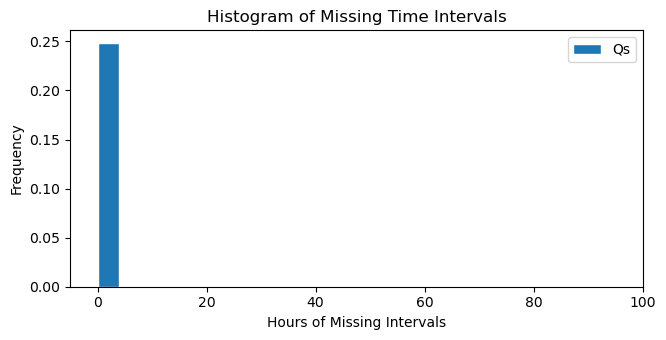

('original', 'Qin') missing intervals <= 4h:  32.56%.
('original', 'Qin') missing intervals <= 0.5h:  0.00%.
14 43


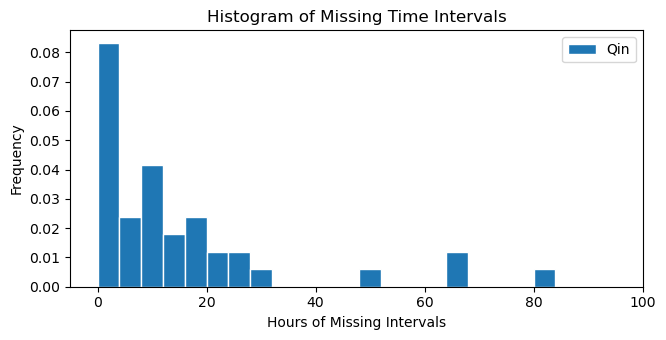

('original', 'Qac') missing intervals <= 4h:  27.03%.
('original', 'Qac') missing intervals <= 0.5h:  10.81%.
10 37


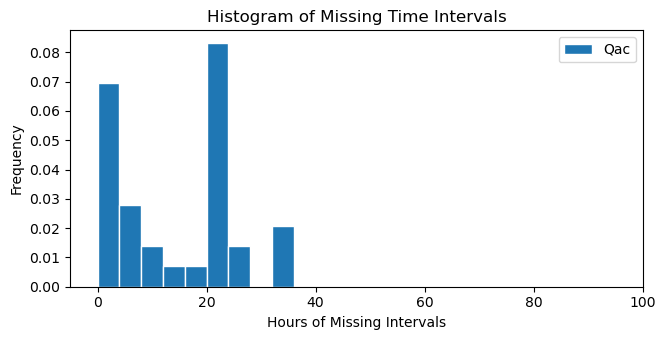

('original', 'Pvrf') missing intervals <= 4h:  53.12%.
('original', 'Pvrf') missing intervals <= 0.5h:  0.00%.
17 32


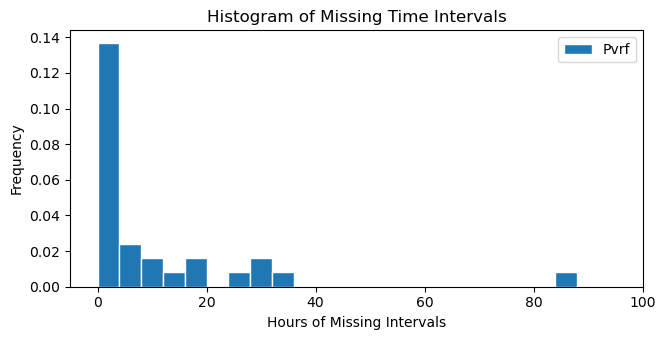

('original', 'Ti0') missing intervals <= 4h:  70.00%.
('original', 'Ti0') missing intervals <= 0.5h:  30.00%.
14 20


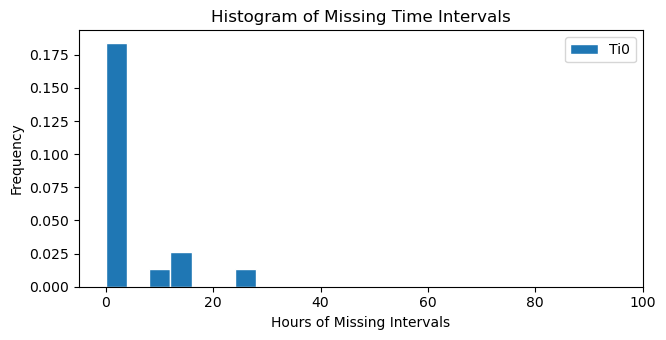

('original', 'Sc0') missing intervals <= 4h:  70.00%.
('original', 'Sc0') missing intervals <= 0.5h:  30.00%.
14 20


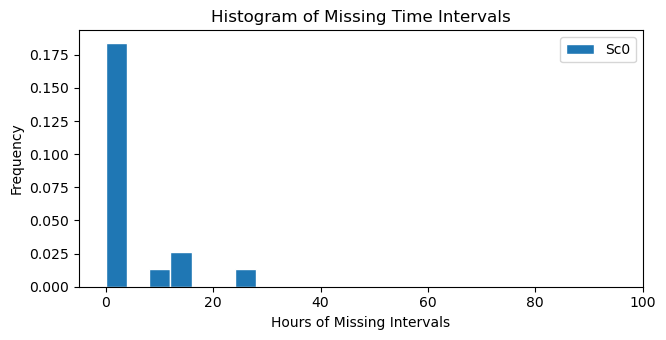

('original', 'Qac0') missing intervals <= 4h:  30.77%.
('original', 'Qac0') missing intervals <= 0.5h:  17.95%.
12 39


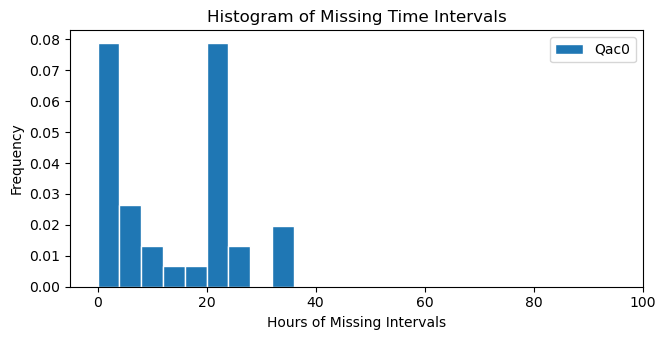

('original', 'Ti1') missing intervals <= 4h:  72.22%.
('original', 'Ti1') missing intervals <= 0.5h:  33.33%.
13 18


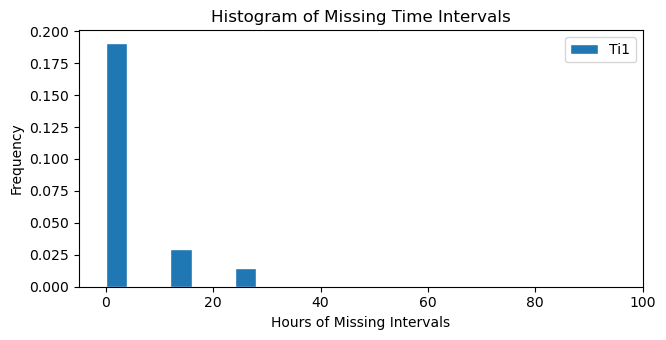

('original', 'Sc1') missing intervals <= 4h:  72.22%.
('original', 'Sc1') missing intervals <= 0.5h:  33.33%.
13 18


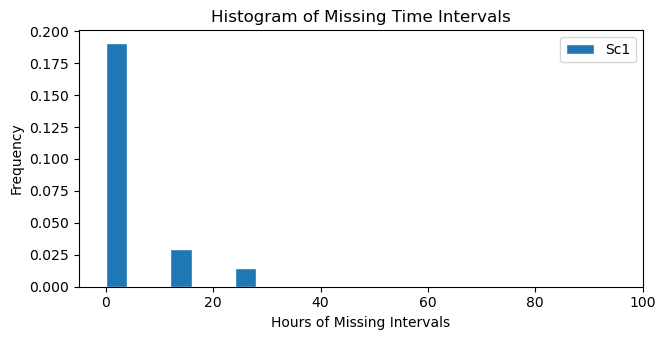

('original', 'Qac1') missing intervals <= 4h:  30.77%.
('original', 'Qac1') missing intervals <= 0.5h:  17.95%.
12 39


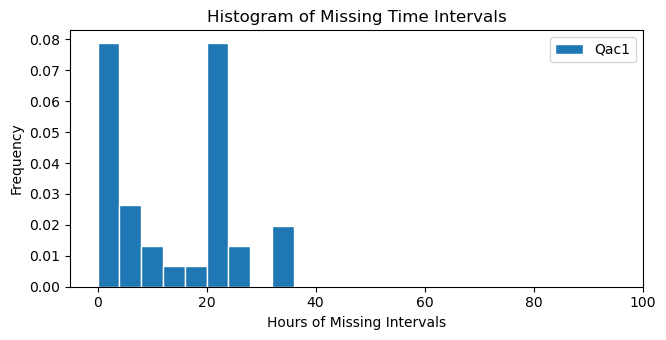

('original', 'Ti2') missing intervals <= 4h:  70.00%.
('original', 'Ti2') missing intervals <= 0.5h:  30.00%.
14 20


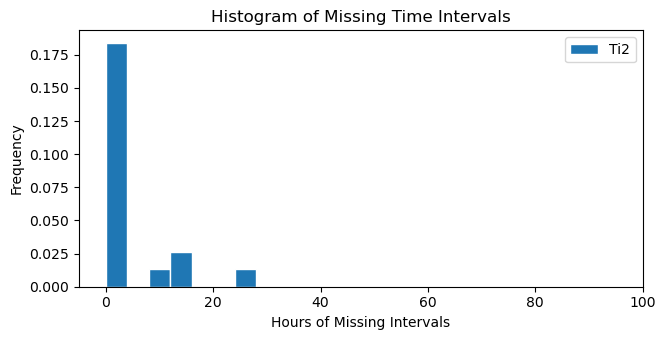

('original', 'Sc2') missing intervals <= 4h:  70.00%.
('original', 'Sc2') missing intervals <= 0.5h:  30.00%.
14 20


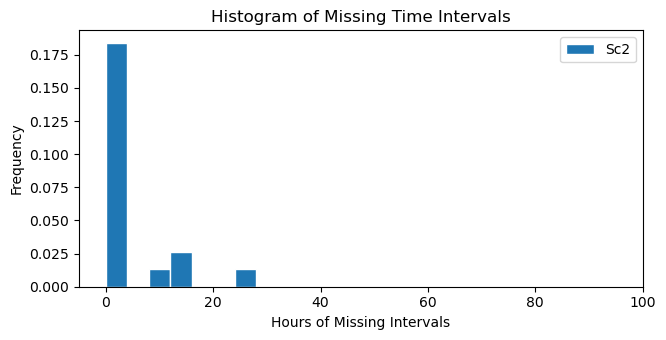

('original', 'Qac2') missing intervals <= 4h:  30.77%.
('original', 'Qac2') missing intervals <= 0.5h:  17.95%.
12 39


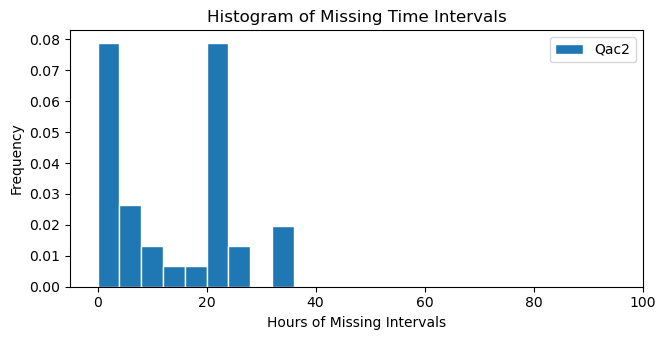


Multi----------------------------------------
original: 同时无缺失的数据条数为1743, 占比为 17.97%.
original: 范围内同时无缺失的数据条数为1731, 占比为 17.85%.


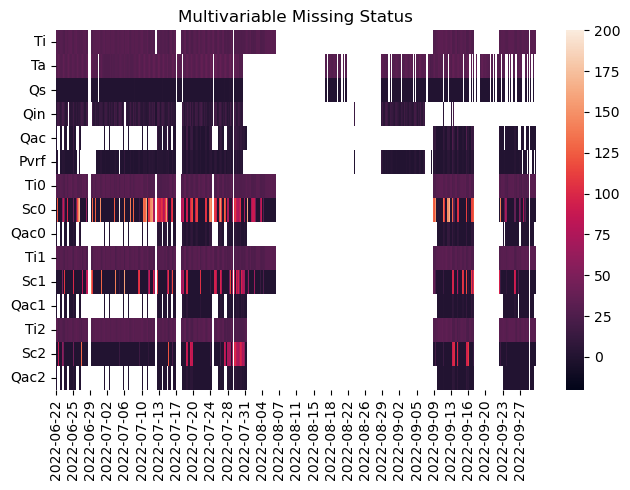


Consistency----------------------------------------
original: 合理的COP数据条数为1551, 范围内的COP数据条数为1327, 占比为 85.56%.


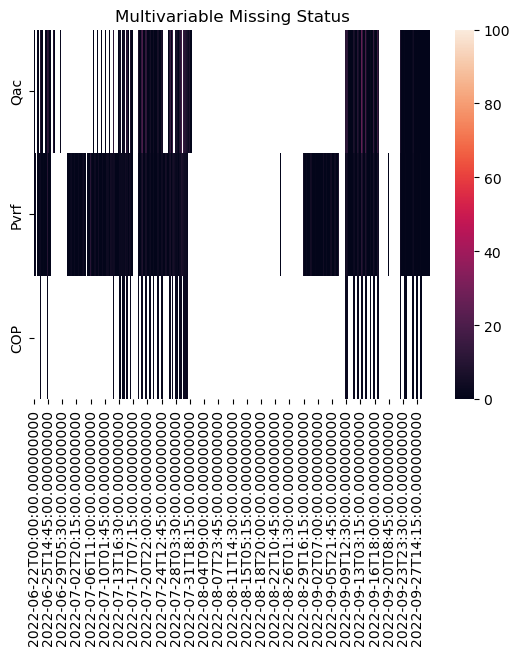

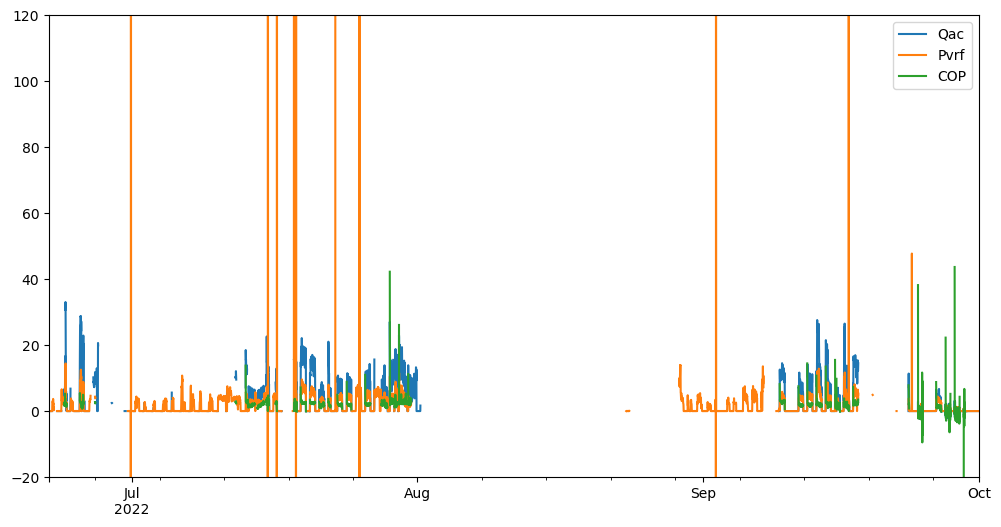

In [5]:
dqa = data_quality_assessment.DQA(data=data, **params)
dqa.assess()